# Kilian (2009) replication, 1973–2007

Thin interactive wrapper over `src/oil_models`. See `docs/` for the methodology and `reports/RESULTS.md` for the full generated results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oil_models import data_prep, hormuz, kilian_var as kv, scenarios, evaluate, benchmarks, regression, combine, volatility, external_data

In [2]:
orig = data_prep.load_kilian_original()
m = kv.fit(orig)
kv.stable(m)

(True, 0.9885919975246531)

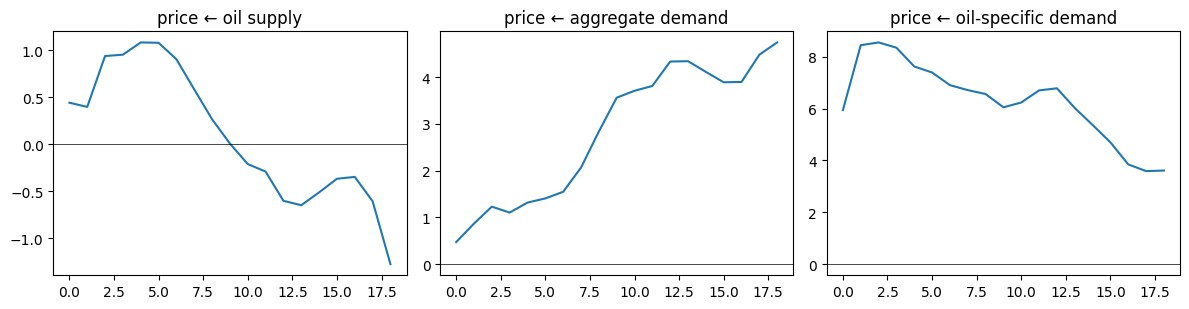

In [3]:
theta = kv.irf(m, 18)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for s_ in range(3):
    axes[s_].plot(theta[:, 2, s_]); axes[s_].axhline(0, c='k', lw=.5)
    axes[s_].set_title(f'price ← {kv.SHOCK_NAMES[s_]}')
plt.tight_layout()

In [4]:
f = kv.fevd(m, 18)
pd.DataFrame(f[[1,6,12,18],2,:], columns=kv.SHOCK_NAMES, index=[1,6,12,18])

,oil supply,aggregate demand,oil-specific demand
1,0.003257,0.009049,0.987694
6,0.012419,0.023106,0.964475
12,0.008209,0.108792,0.882999
18,0.009175,0.192060,0.798765


## Historical decomposition — the 2003–08 run-up should be aggregate demand

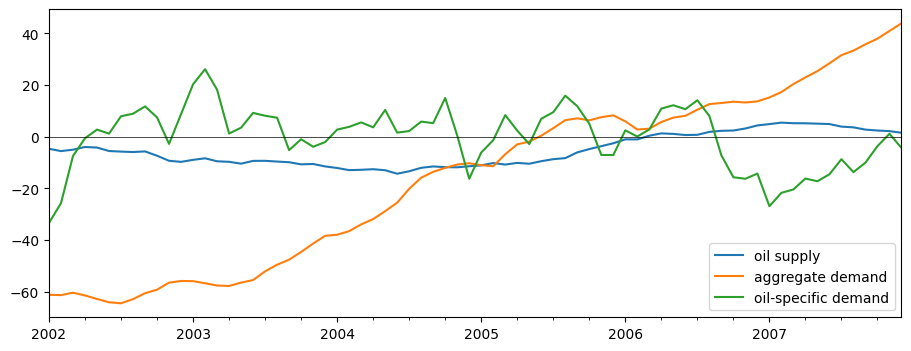

In [5]:
hd = kv.historical_decomposition(m)['ln_real_oil_price']
hd[kv.SHOCK_NAMES].loc['2002':].plot(figsize=(11,4)); plt.axhline(0, c='k', lw=.5);